# Урок 1. Линейная алгебра: векторы, матрицы, SVD

🎯 **Цели урока**

- почувствовать скалярное произведение и косинус на настоящих эмбеддингах;
- увидеть матрицу как преобразование и посчитать стоимость матричного умножения;
- спроецировать эмбеддинги на «смысловое направление»;
- сжать данные через SVD и понять, почему LoRA экономит параметры.

📖 **Теория:** раздел «Линейная алгебра».

⏱ Эмбеддинги считает модель bge-m3 (роль `embed`); ответы записаны в кассеты `./cassettes`,
поэтому урок выполняется и без запущенной Ollama.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

import mlcourse
from mlcourse import embed

np.set_printoptions(precision=3, suppress=True)
print(mlcourse.describe_settings())

main   qwen3.8-27b  https://<удалённый сервер>/v1
local  qwen3:8b     http://localhost:11434/v1
embed  bge-m3       http://localhost:11434/v1
кэш    record       LLM_CACHE


## 1. Скалярное произведение и косинус

Скалярное произведение зависит и от угла между векторами, и от их длины. Косинус — только от угла.

In [2]:
def cosine(x: np.ndarray, y: np.ndarray) -> float:
    return float(x @ y / (np.linalg.norm(x) * np.linalg.norm(y)))


a = np.array([3.0, 4.0])
b = np.array([4.0, 3.0])
for name, v in [("b", b), ("10·b", 10 * b), ("−a", -a), ("перпендикуляр", np.array([-4.0, 3.0]))]:
    print(f"a и {name:14} скалярное = {a @ v:7.1f}   косинус = {cosine(a, v):+.3f}")

a и b              скалярное =    24.0   косинус = +0.960
a и 10·b           скалярное =   240.0   косинус = +0.960
a и −a             скалярное =   -25.0   косинус = -1.000
a и перпендикуляр  скалярное =     0.0   косинус = +0.000


Растянули `b` в 10 раз — скалярное произведение выросло в 10 раз, а косинус не изменился.
Противоположный вектор даёт −1, перпендикулярный — 0.

## 2. Настоящие эмбеддинги

Возьмём предложения на три темы и посмотрим, как модель эмбеддингов расставила их в пространстве.

In [3]:
sentences = [
    "Кошка спит на подоконнике",
    "Котёнок играет с клубком ниток",
    "A cat is sleeping on the windowsill",
    "Центробанк повысил ключевую ставку",
    "Курс доллара вырос на бирже",
    "Инфляция замедлилась во втором квартале",
    "Нейросеть обучают градиентным спуском",
    "Трансформер состоит из слоёв внимания",
]
topics = ["кошки"] * 3 + ["финансы"] * 3 + ["ML"] * 2

E = embed(sentences)
print("форма:", E.shape)
print("нормы:", np.linalg.norm(E, axis=1))

форма: (8, 1024)
нормы: [1. 1. 1. 1. 1. 1. 1. 1.]


Все нормы равны 1: bge-m3 возвращает нормированные векторы. Значит, косинус — это просто
скалярное произведение, а все попарные близости — одно матричное умножение `E @ E.T`.

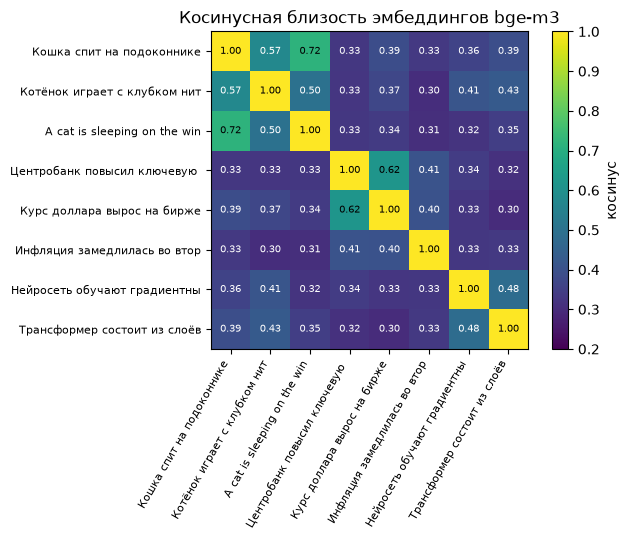

In [4]:
S = E @ E.T

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(S, cmap="viridis", vmin=0.2, vmax=1)
short = [s[:28] for s in sentences]
ax.set_xticks(range(len(short)), short, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(short)), short, fontsize=8)
for i in range(len(S)):
    for j in range(len(S)):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center", fontsize=7, color="w" if S[i, j] < 0.6 else "k")
fig.colorbar(im, label="косинус")
ax.set_title("Косинусная близость эмбеддингов bge-m3")
plt.tight_layout()
plt.show()

Видны три блока: внутри темы близость выше, чем между темами. Русское и английское
предложения про кошку оказались рядом: bge-m3 — многоязычная модель, смысл важнее языка.

### Поиск ближайших — одно умножение

Это ядро любого векторного поиска (M11): эмбеддинг запроса умножаем на матрицу эмбеддингов
документов и берём наибольшие значения.

In [5]:
query = "Как ухаживать за домашним питомцем?"
q = embed(query)[0]
scores = E @ q
for i in np.argsort(-scores)[:3]:
    print(f"{scores[i]:.3f}  {sentences[i]}")

0.526  Кошка спит на подоконнике
0.481  Котёнок играет с клубком ниток
0.402  A cat is sleeping on the windowsill


## 3. Матрица как преобразование

Матрица поворота $R$ и растяжения $D$. Проверим, что порядок применения важен: $RD \ne DR$.

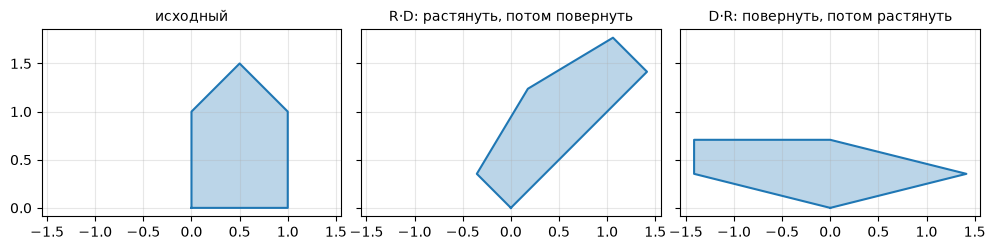

R·D =
 [[ 1.414 -0.354]
 [ 1.414  0.354]] 
D·R =
 [[ 1.414 -1.414]
 [ 0.354  0.354]]


In [6]:
phi = np.pi / 4
R = np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])
D = np.array([[2.0, 0.0], [0.0, 0.5]])

house = np.array([[0, 0], [1, 0], [1, 1], [0.5, 1.5], [0, 1], [0, 0]]).T  # [2, 6]: точки — столбцы

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharex=True, sharey=True)
for ax, (title, m) in zip(axes, [("исходный", np.eye(2)), ("R·D: растянуть, потом повернуть", R @ D),
                                 ("D·R: повернуть, потом растянуть", D @ R)]):
    pts = m @ house
    ax.fill(pts[0], pts[1], alpha=0.3)
    ax.plot(pts[0], pts[1])
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("R·D =\n", R @ D, "\nD·R =\n", D @ R)

### Формы тензоров

В моделях линейный слой применяется к последней оси тензора `[batch, seq, d]`.
`@` в NumPy и PyTorch умеет работать с «пакетами» матриц.

In [7]:
rng = np.random.default_rng(0)
x = rng.normal(size=(2, 5, 16))   # [batch=2, seq=5, d=16]
W = rng.normal(size=(16, 4))      # [d=16, d_out=4]
y = x @ W
print(x.shape, "@", W.shape, "→", y.shape)

(2, 5, 16) @ (16, 4) → (2, 5, 4)


### 📏 Сколько стоит умножение

Умножение матриц $n \times n$ — это $2n^3$ операций. Измерим, сколько миллиардов операций
в секунду (GFLOP/s) выдаёт процессор этого компьютера.

In [8]:
def matmul_gflops(n: int, repeats: int = 5, dtype=np.float32) -> float:
    a = rng.normal(size=(n, n)).astype(dtype)
    b = rng.normal(size=(n, n)).astype(dtype)
    a @ b  # прогрев
    start = time.perf_counter()
    for _ in range(repeats):
        a @ b
    elapsed = (time.perf_counter() - start) / repeats
    return 2 * n**3 / elapsed / 1e9


for n in [256, 1024, 2048]:
    print(f"n = {n:5}: {matmul_gflops(n):8.0f} GFLOP/s")

n =   256:     1132 GFLOP/s
n =  1024:     1116 GFLOP/s


n =  2048:      921 GFLOP/s


Прямой проход модели с $N$ параметрами стоит около $2N$ FLOPs на токен. Прикинем, сколько
токенов в секунду этот процессор смог бы «прожевать» для модели на 8 млрд параметров, если бы
упирался только в вычисления:

In [9]:
gflops = matmul_gflops(2048)
n_params = 8e9
print(f"≈ {gflops * 1e9 / (2 * n_params):.0f} токенов/с — предел по вычислениям")

≈ 58 токенов/с — предел по вычислениям


Вычислительный предел — десятки или сотни токенов в секунду. В M00 мы видели, что генерация
идёт медленнее — около 7 ток/с. Генерация одного токена упирается не в вычисления,
а в чтение весов из памяти. А вот чтение промпта (prefill) обрабатывает много токенов за раз
и упирается как раз в вычисления. Подробно — в M08.

## 4. Проекции и «смысловое направление»

Проекция вектора $v$ на направление $u$: $\frac{v \cdot u}{u \cdot u} u$. Остаток перпендикулярен $u$.

In [10]:
def project(v: np.ndarray, u: np.ndarray) -> np.ndarray:
    return (v @ u) / (u @ u) * u


v = np.array([2.0, 3.0])
u = np.array([1.0, 0.5])
p = project(v, u)
print("проекция:", p, " остаток·u =", round(float((v - p) @ u), 12))

проекция: [2.8 1.4]  остаток·u = 0.0


Разность средних эмбеддингов двух тем — направление «кошки → финансы». Проецируем на него все
предложения и получаем одно число вместо 1024. Оно показывает, к какой теме ближе текст.

In [11]:
direction = E[3:6].mean(axis=0) - E[:3].mean(axis=0)
direction /= np.linalg.norm(direction)

extra = ["Собака грызёт кость", "Акции упали после отчёта", "Модель переобучилась на трейне"]
coords = np.vstack([E, embed(extra)]) @ direction
labels = sentences + extra
for c, s in sorted(zip(coords, labels)):
    print(f"{c:+.3f}  {s}")

-0.490  A cat is sleeping on the windowsill
-0.490  Кошка спит на подоконнике
-0.425  Котёнок играет с клубком ниток
-0.261  Собака грызёт кость
-0.087  Трансформер состоит из слоёв внимания
-0.070  Модель переобучилась на трейне
-0.036  Нейросеть обучают градиентным спуском
+0.125  Акции упали после отчёта
+0.342  Инфляция замедлилась во втором квартале
+0.365  Курс доллара вырос на бирже
+0.410  Центробанк повысил ключевую ставку


Новые предложения, которых не было при построении направления, встали на свои места: «собака» —
к кошкам, «акции» — к финансам, ML — посередине. Так в эмбеддингах ищут «оси смысла».
На этой же идее построены методы управления поведением LLM через активации (steering vectors).

## 5. SVD: сжатие данных

Матрица 1797 × 64: 1797 рукописных цифр по 8 × 8 пикселей (датасет digits из scikit-learn,
лицензия CC BY 4.0).

In [12]:
X = load_digits().data
mean = X.mean(axis=0)
Xc = X - mean
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
print("U", U.shape, " s", s.shape, " Vt", Vt.shape)
print("первые сингулярные числа:", s[:6].round(0))

energy = np.cumsum(s**2) / np.sum(s**2)
for share in [0.5, 0.8, 0.9, 0.99]:
    print(f"{share:.0%} энергии — ранг {np.searchsorted(energy, share) + 1}")

U (1797, 64)  s (64,)  Vt (64, 64)
первые сингулярные числа: [567. 542. 505. 426. 353. 326.]
50% энергии — ранг 5
80% энергии — ранг 13
90% энергии — ранг 21
99% энергии — ранг 41


Проверим теорему Эккарта — Янга: ошибка приближения ранга $k$ равна корню из суммы квадратов
отброшенных сингулярных чисел.

In [13]:
for k in [5, 10, 20]:
    Xk = (U[:, :k] * s[:k]) @ Vt[:k]
    direct = np.linalg.norm(Xc - Xk)
    formula = np.sqrt(np.sum(s[k:] ** 2))
    stored = k * (X.shape[0] + X.shape[1] + 1)
    print(f"k={k:2}: ошибка {direct:8.1f} (по формуле {formula:8.1f}), "
          f"хранить {stored:6} чисел вместо {X.size} ({stored / X.size:.0%})")

k= 5: ошибка    991.2 (по формуле    991.2), хранить   9310 чисел вместо 115008 (8%)
k=10: ошибка    751.8 (по формуле    751.8), хранить  18620 чисел вместо 115008 (16%)
k=20: ошибка    477.7 (по формуле    477.7), хранить  37240 чисел вместо 115008 (32%)


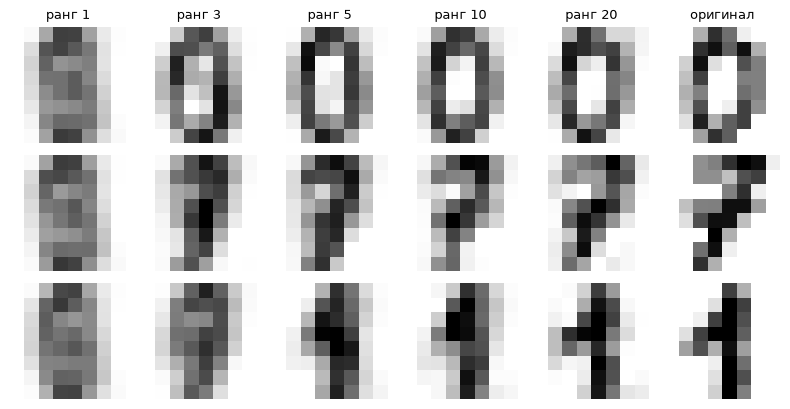

In [14]:
fig, axes = plt.subplots(3, 6, figsize=(8, 4.2))
for row, idx in enumerate([0, 7, 42]):
    for col, k in enumerate([1, 3, 5, 10, 20, 64]):
        img = (U[idx, :k] * s[:k]) @ Vt[:k] + mean
        axes[row, col].imshow(img.reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title("оригинал" if k == 64 else f"ранг {k}", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Низкий ранг и LoRA

При дообучении LoRA ищет изменение весов в виде $\Delta W = BA$ ранга $r$. Посчитаем экономию
для всех линейных слоёв модели с архитектурой Qwen3-8B: скрытая размерность 4096,
промежуточная (MLP) 12288, 8 голов для K и V по 128, 36 слоёв.

In [15]:
d, d_ff, d_kv, n_layers, r = 4096, 12288, 8 * 128, 36, 16
layers = {  # имя: (вход, выход)
    "q_proj": (d, d), "k_proj": (d, d_kv), "v_proj": (d, d_kv), "o_proj": (d, d),
    "gate_proj": (d, d_ff), "up_proj": (d, d_ff), "down_proj": (d_ff, d),
}
full = sum(i * o for i, o in layers.values()) * n_layers
lora = sum(r * (i + o) for i, o in layers.values()) * n_layers
print(f"линейные слои: {full / 1e9:.2f} млрд параметров")
print(f"LoRA r={r}:     {lora / 1e6:.1f} млн параметров ({lora / full:.2%})")

линейные слои: 6.95 млрд параметров
LoRA r=16:     43.6 млн параметров (0.63%)


Меньше процента параметров. Но работает ли это? LoRA опирается на наблюдение: изменение весов
при дообучении близко к низкоранговому. Смоделируем такое изменение — ранг 4 плюс небольшой
шум — и посмотрим, что покажет SVD.

сингулярные числа ΔW: [1.106 1.035 0.999 0.949 0.089 0.089 0.088 0.088]


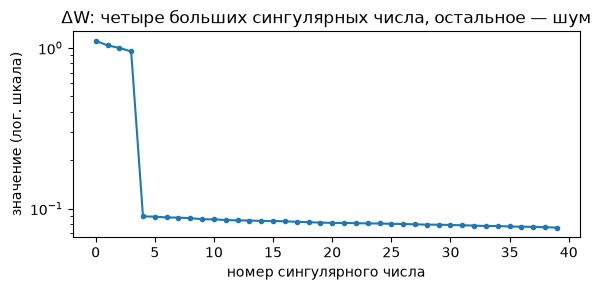

In [16]:
n = 512
B = rng.normal(size=(n, 4))
A = rng.normal(size=(4, n))
delta = B @ A / n + 0.002 * rng.normal(size=(n, n))
sv = np.linalg.svd(delta, compute_uv=False)
print("сингулярные числа ΔW:", sv[:8].round(3))

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(sv[:40], marker="o", ms=3)
ax.set_xlabel("номер сингулярного числа")
ax.set_ylabel("значение (лог. шкала)")
ax.set_title("ΔW: четыре больших сингулярных числа, остальное — шум")
plt.tight_layout()
plt.show()

Четыре больших числа и «шумовой пол». Приближение ранга 4 почти без потерь описывает $\Delta W$,
а хранит в 64 раза меньше чисел ($2 \cdot 512 \cdot 4$ вместо $512^2$).

## ✅ Итоги

- Косинус измеряет направление, скалярное произведение — ещё и длину. Для нормированных
  эмбеддингов это одно и то же, а поиск ближайших — одно матричное умножение.
- Матрица — преобразование, произведение — композиция, порядок важен. Умножение $n \times n$
  стоит $2n^3$ FLOPs, прямой проход модели — около $2N$ FLOPs на токен.
- Проекция на направление превращает вектор в одно осмысленное число.
- SVD даёт лучшее низкоранговое приближение. На этом стоят PCA и LoRA.

✍️ **Упражнения:** `exercises/ex01_vectors.py` и `exercises/ex02_svd.py`, проверка — `make test M=01`.